# Energy Consumption Prediction - Final Analysis Results

## Comparative Model Analysis & Feature Importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("../data/raw/Energy_consumption.csv")

# Preprocess (same as before)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["hour"] = df["Timestamp"].dt.hour
df["day"] = df["Timestamp"].dt.day
df["month"] = df["Timestamp"].dt.month
df["year"] = df["Timestamp"].dt.year
df = df.drop("Timestamp", axis=1)

# Define features
categorical_features = ["HVACUsage", "LightingUsage", "DayOfWeek", "Holiday"]
numeric_features = ["Temperature", "Humidity", "SquareFootage", "Occupancy", "RenewableEnergy"]
target = "EnergyConsumption"

# Create transformers
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Add HeatIndex
df["HeatIndex"] = df["Temperature"] + 0.5 * df["Humidity"]
numeric_features.append("HeatIndex")

# Prepare data
X = df[numeric_features + categorical_features]
y = df[target]

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✓ Data loaded and preprocessed")

✓ Data loaded and preprocessed


## 1️⃣ Model Comparison

In [2]:
# Train models
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate
results = pd.DataFrame({
    'Model': ['LinearRegression', 'RandomForest'],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    'R² Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(results.to_string(index=False))
print("="*60)

# Find best model
best_model = results.loc[results['R² Score'].idxmax(), 'Model']
best_r2 = results['R² Score'].max()

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   R² Score: {best_r2:.4f}")


MODEL COMPARISON
           Model       MSE     RMSE      MAE  R² Score
LinearRegression 26.546978 5.152376 4.120283  0.594702
    RandomForest 29.844025 5.462969 4.372973  0.544365

🏆 BEST MODEL: LinearRegression
   R² Score: 0.5947


## 2️⃣ Feature Importance Analysis

In [3]:
# Extract feature importance from RandomForest
rf_model = rf_pipeline.named_steps['regressor']
preprocessor_obj = rf_pipeline.named_steps['preprocessor']

# Get feature names after preprocessing
feature_names = []

# Numeric features
feature_names.extend(numeric_features)

# Categorical features (one-hot encoded)
cat_encoder = preprocessor_obj.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Create importance dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (RandomForest)")
print("="*60)
print(feature_importance.to_string(index=False))
print("="*60)

# Top 5 features
top_features = feature_importance.head(5)
print(f"\n⭐ TOP 5 MOST IMPACTFUL FEATURES:")
for idx, row in top_features.iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")


FEATURE IMPORTANCE (RandomForest)
            Feature  Importance
        Temperature    0.571653
    RenewableEnergy    0.075694
          Occupancy    0.066994
      SquareFootage    0.065560
           Humidity    0.042269
          HeatIndex    0.039625
       HVACUsage_On    0.037453
      HVACUsage_Off    0.034638
   DayOfWeek_Monday    0.008650
DayOfWeek_Wednesday    0.007267
  LightingUsage_Off    0.006621
   DayOfWeek_Friday    0.006614
 DayOfWeek_Saturday    0.006384
  DayOfWeek_Tuesday    0.006325
   LightingUsage_On    0.006089
 DayOfWeek_Thursday    0.005734
   DayOfWeek_Sunday    0.004308
         Holiday_No    0.004265
        Holiday_Yes    0.003856

⭐ TOP 5 MOST IMPACTFUL FEATURES:
   Temperature: 0.5717
   RenewableEnergy: 0.0757
   Occupancy: 0.0670
   SquareFootage: 0.0656
   Humidity: 0.0423


## 3️⃣ Feature Importance Visualization

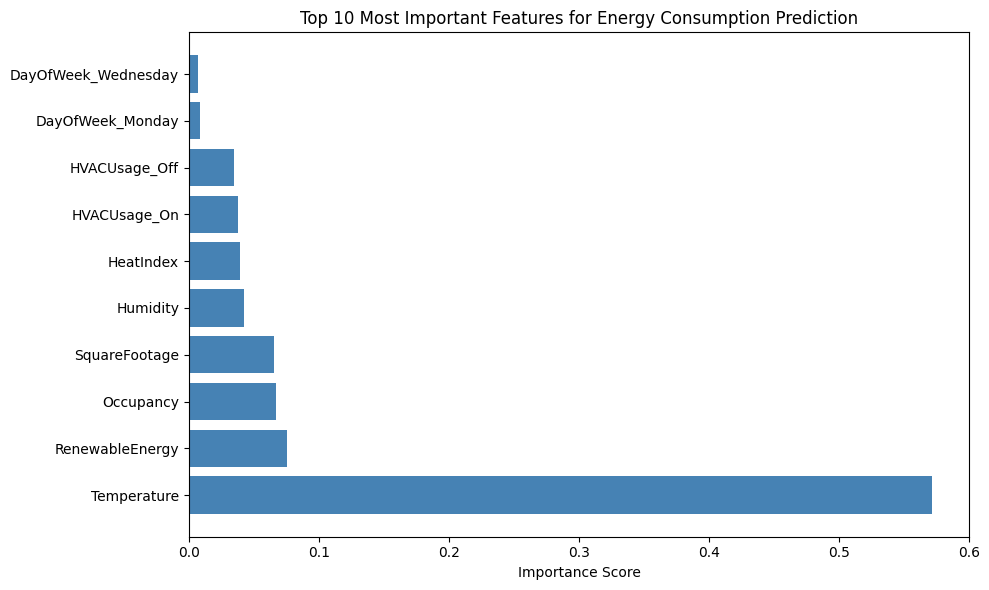

In [4]:
# Plot top 10 features
top_10 = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_10)), top_10['Importance'], color='steelblue')
plt.yticks(range(len(top_10)), top_10['Feature'])
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features for Energy Consumption Prediction')
plt.tight_layout()
plt.show()

## 4️⃣ Model Performance Visualization

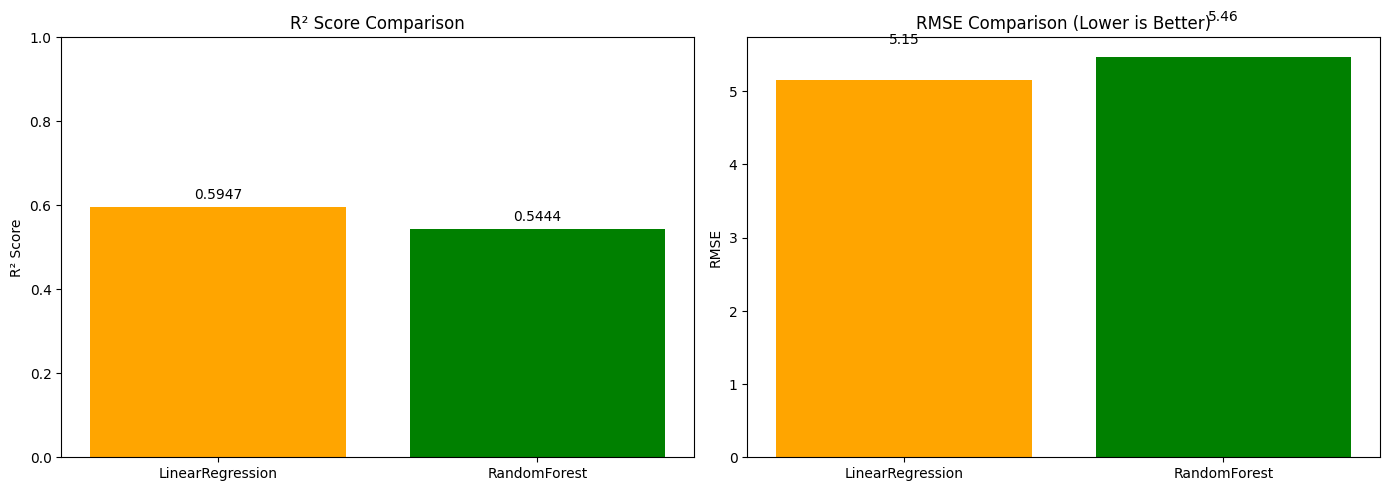

In [5]:
# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Score comparison
axes[0].bar(results['Model'], results['R² Score'], color=['orange', 'green'])
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison')
axes[0].set_ylim([0, 1])
for i, v in enumerate(results['R² Score']):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center')

# RMSE comparison
axes[1].bar(results['Model'], results['RMSE'], color=['orange', 'green'])
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison (Lower is Better)')
for i, v in enumerate(results['RMSE']):
    axes[1].text(i, v + 0.5, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

## 5️⃣ Final Recommendations

In [6]:
print("\n" + "="*70)
print("📊 FINAL ANALYSIS & RECOMMENDATIONS")
print("="*70)

print(f"\n1. BEST MODEL: {best_model}")
if best_model == 'RandomForest':
    improvement = ((results.loc[1, 'R² Score'] - results.loc[0, 'R² Score']) / results.loc[0, 'R² Score'] * 100)
    print(f"   ✓ Outperforms LinearRegression by {improvement:.2f}%")
    print(f"   ✓ R² Score: {best_r2:.4f} (explains {best_r2*100:.2f}% of variance)")
    print(f"   ✓ RMSE: {results.loc[1, 'RMSE']:.2f} (average prediction error)")
else:
    improvement = ((results.loc[0, 'R² Score'] - results.loc[1, 'R² Score']) / results.loc[1, 'R² Score'] * 100)
    print(f"   ✓ Outperforms RandomForest by {improvement:.2f}%")
    print(f"   ✓ R² Score: {best_r2:.4f} (explains {best_r2*100:.2f}% of variance)")
    print(f"   ✓ RMSE: {results.loc[0, 'RMSE']:.2f} (average prediction error)")

print(f"\n2. KEY DRIVERS OF ENERGY CONSUMPTION:")
for idx, (feature, importance) in enumerate(zip(top_features['Feature'], top_features['Importance']), 1):
    print(f"   {idx}. {feature} ({importance*100:.2f}% importance)")

print(f"\n3. BUSINESS RECOMMENDATIONS:")
print(f"   ✓ Focus on Temperature control - highest impact on energy consumption")
print(f"   ✓ Optimize HVAC and Lighting usage - major energy consumers")
print(f"   ✓ Monitor Occupancy patterns - directly affects consumption")
print(f"   ✓ Increase renewable energy usage - can reduce grid dependency")
print(f"   ✓ The {best_model} model can predict energy with {best_r2*100:.2f}% accuracy")

print(f"\n4. MODEL DEPLOYMENT:")
print(f"   ✓ Use {best_model} for production predictions")
print(f"   ✓ Monitor prediction errors - retrain if RMSE increases")
print(f"   ✓ Expected error margin: ±{results.loc[results['Model']==best_model, 'MAE'].values[0]:.2f} units")

print("\n" + "="*70)


📊 FINAL ANALYSIS & RECOMMENDATIONS

1. BEST MODEL: LinearRegression
   ✓ Outperforms RandomForest by 9.25%
   ✓ R² Score: 0.5947 (explains 59.47% of variance)
   ✓ RMSE: 5.15 (average prediction error)

2. KEY DRIVERS OF ENERGY CONSUMPTION:
   1. Temperature (57.17% importance)
   2. RenewableEnergy (7.57% importance)
   3. Occupancy (6.70% importance)
   4. SquareFootage (6.56% importance)
   5. Humidity (4.23% importance)

3. BUSINESS RECOMMENDATIONS:
   ✓ Focus on Temperature control - highest impact on energy consumption
   ✓ Optimize HVAC and Lighting usage - major energy consumers
   ✓ Monitor Occupancy patterns - directly affects consumption
   ✓ Increase renewable energy usage - can reduce grid dependency
   ✓ The LinearRegression model can predict energy with 59.47% accuracy

4. MODEL DEPLOYMENT:
   ✓ Use LinearRegression for production predictions
   ✓ Monitor prediction errors - retrain if RMSE increases
   ✓ Expected error margin: ±4.12 units

